# **Forecasting de ventas 2025**

In [1]:
# importe de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays

**Carga de archivo de ventas para inferencia**

In [2]:
# Cargar datos de inferencia (octubre real + noviembre con unidades_vendidas por predecir)
df_inferencia = pd.read_csv('../data/raw/inferencia/ventas_2025_inferencia.csv')
df_inferencia['fecha'] = pd.to_datetime(df_inferencia['fecha'])

print(f"Forma: {df_inferencia.shape}")
display(df_inferencia.head())

Forma: (888, 13)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2025-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,26.0,113.13,2941.38,89.51,113.43,104.78
1,2025-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,27.0,141.89,3831.03,128.73,112.91,122.88
2,2025-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,5.0,85.79,428.95,84.28,74.51,85.57
3,2025-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,3.0,76.19,228.57,75.54,70.32,71.13
4,2025-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,3.0,35.48,106.44,33.84,31.32,34.41


In [3]:
# ============================================================================
# CREACIÓN DE VARIABLES TEMPORALES Y DE CALENDARIO - ESPAÑA
# ============================================================================
df = df_inferencia.sort_values(['fecha', 'producto_id']).reset_index(drop=True)

es_holidays = holidays.Spain()

df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['día_mes'] = df['fecha'].dt.day
df['día_semana'] = df['fecha'].dt.day_name()
df['día_semana_num'] = df['fecha'].dt.dayofweek

df['es_fin_semana'] = df['día_semana_num'].isin([5, 6])
df['es_lunes'] = (df['día_semana_num'] == 0)
df['es_viernes'] = (df['día_semana_num'] == 4)
df['es_sabado'] = (df['día_semana_num'] == 5)
df['es_domingo'] = (df['día_semana_num'] == 6)

df['es_festivo'] = df['fecha'].apply(lambda x: True if x in es_holidays else False)
df['nombre_festivo'] = df['fecha'].apply(lambda x: es_holidays.get(x, None))

def es_black_friday(fecha):
    if fecha.month != 11:
        return False
    ultimo_dia_nov = pd.Timestamp(fecha.year, 11, 30)
    dias_desde_viernes = (ultimo_dia_nov.dayofweek - 4) % 7
    ultimo_viernes = ultimo_dia_nov - pd.Timedelta(days=dias_desde_viernes)
    return True if fecha.date() == ultimo_viernes.date() else False

def es_cyber_monday(fecha):
    if fecha.month != 11 and fecha.month != 12:
        return False
    if fecha.month == 11:
        ultimo_dia_nov = pd.Timestamp(fecha.year, 11, 30)
        dias_desde_viernes = (ultimo_dia_nov.dayofweek - 4) % 7
        ultimo_viernes = ultimo_dia_nov - pd.Timedelta(days=dias_desde_viernes)
        cyber_monday = ultimo_viernes + pd.Timedelta(days=3)
    else:
        primer_dia_dic = pd.Timestamp(fecha.year, 12, 1)
        dias_hasta_lunes = (7 - primer_dia_dic.dayofweek) % 7
        if dias_hasta_lunes == 0 and primer_dia_dic.dayofweek == 0:
            cyber_monday = primer_dia_dic
        else:
            cyber_monday = primer_dia_dic + pd.Timedelta(days=dias_hasta_lunes if dias_hasta_lunes != 0 else 7)
        return True if fecha.date() == cyber_monday.date() else False
    return True if fecha.date() == cyber_monday.date() else False

df['es_black_friday'] = df['fecha'].apply(es_black_friday)
df['es_cyber_monday'] = df['fecha'].apply(es_cyber_monday)

df['es_temporada_navidad'] = ((df['mes'] == 11) | (df['mes'] == 12))
df['es_inicio_año'] = df['mes'].isin([1, 2])
df['es_verano'] = df['mes'].isin([6, 7, 8])
df['es_cuarentena_pascua'] = df['mes'].isin([3, 4])

df['num_semana'] = df['fecha'].dt.isocalendar().week
df['trimestre'] = df['fecha'].dt.quarter
df['día_año'] = df['fecha'].dt.dayofyear
df['días_hasta_fin_año'] = 365 - df['día_año']
df.loc[df['año'] % 4 == 0, 'días_hasta_fin_año'] = 366 - df['día_año']
df['mes_tiene_31_dias'] = df['mes'].isin([1, 3, 5, 7, 8, 10, 12])
df['día_en_mes'] = df['día_mes']
df['es_fin_mes'] = (df['día_mes'] >= 28)
df['es_inicio_mes'] = (df['día_mes'] <= 3)

# A diferencia de entrenamiento: aquí también excluimos unidades_vendidas e
# ingresos del dropna, porque son NaN para todo noviembre A PROPÓSITO
# (es justo lo que vamos a predecir). Si no las excluyéramos, perderíamos
# todo noviembre en este paso.
cols_para_eliminar_nulos = [
    col for col in df.columns
    if col not in ['nombre_festivo', 'día_semana', 'unidades_vendidas', 'ingresos']
]
df = df.dropna(subset=cols_para_eliminar_nulos)

print(f"Dataframe con variables de calendario: {df.shape}")
print(df.groupby(df['fecha'].dt.to_period('M')).size())

Dataframe con variables de calendario: (888, 39)
fecha
2025-10    168
2025-11    720
Freq: M, dtype: int64


In [4]:
# ============================================================================
# CREACIÓN DE VARIABLE DESCUENTO PORCENTUAL
# ============================================================================
df['descuento_porcentaje'] = ((df['precio_base'] - df['precio_venta']) / df['precio_base']) * 100

print(f"Descuento medio: {df['descuento_porcentaje'].mean():.2f}%")
print(f"Nulos en descuento_porcentaje: {df['descuento_porcentaje'].isnull().sum()}")

Descuento medio: 0.42%
Nulos en descuento_porcentaje: 0


In [5]:
# ============================================================================
# CREACIÓN DE VARIABLES DE COMPETENCIA (sin eliminar columnas esta vez)
# ============================================================================
df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

print("✓ precio_competencia y ratio_precio creadas")
print("Se conservan Amazon, Decathlon, Deporvillage, precio_venta y precio_competencia")
print("(el modelo no las usa directamente, pero la app las necesitará para simular escenarios)")

✓ precio_competencia y ratio_precio creadas
Se conservan Amazon, Decathlon, Deporvillage, precio_venta y precio_competencia
(el modelo no las usa directamente, pero la app las necesitará para simular escenarios)


In [6]:
# ============================================================================
# LAGS Y MEDIA MÓVIL — mismo cálculo que en entrenamiento
# ============================================================================
df = df.sort_values(['producto_id', 'fecha']).reset_index(drop=True)

for lag in range(1, 8):
    df[f'lag_{lag}_unidades_vendidas'] = (
        df.groupby('producto_id')['unidades_vendidas'].shift(lag)
    )

df['media_movil_7_unidades_vendidas'] = (
    df.groupby('producto_id')['unidades_vendidas']
      .transform(lambda s: s.shift(1).rolling(window=7, min_periods=1).mean())
)

lag_cols = [f'lag_{i}_unidades_vendidas' for i in range(1, 8)]
lag_cols.append('media_movil_7_unidades_vendidas')

# IMPORTANTE: aquí NO hacemos dropna(). Solo el 1 de noviembre tiene lags
# 100% reales (calculados con datos reales de octubre). A partir del día 2,
# pandas seguiría rellenando algo con rolling(min_periods=1), pero sería un
# valor parcial y engañoso. Lo anulamos a propósito para que no se pueda usar
# sin darse cuenta: esos días los completará la futura app de forma recursiva,
# día a día, con sus propias predicciones.
es_noviembre = df['fecha'].dt.month == 11
es_uno_noviembre = df['fecha'] == pd.Timestamp('2025-11-01')
filas_a_limpiar = es_noviembre & ~es_uno_noviembre

df.loc[filas_a_limpiar, lag_cols] = np.nan

print("Nulos en lags — 1 de noviembre (deben ser 0, todos reales):")
print(df.loc[df['fecha'] == pd.Timestamp('2025-11-01'), lag_cols].isnull().sum())

print("\nNulos en lags — resto de noviembre (deben ser todos, a propósito):")
print(df.loc[filas_a_limpiar, lag_cols].isnull().sum())

Nulos en lags — 1 de noviembre (deben ser 0, todos reales):
lag_1_unidades_vendidas            0
lag_2_unidades_vendidas            0
lag_3_unidades_vendidas            0
lag_4_unidades_vendidas            0
lag_5_unidades_vendidas            0
lag_6_unidades_vendidas            0
lag_7_unidades_vendidas            0
media_movil_7_unidades_vendidas    0
dtype: int64

Nulos en lags — resto de noviembre (deben ser todos, a propósito):
lag_1_unidades_vendidas            696
lag_2_unidades_vendidas            696
lag_3_unidades_vendidas            696
lag_4_unidades_vendidas            696
lag_5_unidades_vendidas            696
lag_6_unidades_vendidas            696
lag_7_unidades_vendidas            696
media_movil_7_unidades_vendidas    696
dtype: int64


In [7]:
# ============================================================================
# FILTRAR SOLO NOVIEMBRE Y GUARDAR
# ============================================================================
df_inferencia_transformado = df[df['fecha'].dt.month == 11].copy()

print(f"Forma final (solo noviembre): {df_inferencia_transformado.shape}")
print(f"Fechas: {df_inferencia_transformado['fecha'].min().date()} → "
      f"{df_inferencia_transformado['fecha'].max().date()}")

df_inferencia_transformado.to_csv('../data/processed/df_inferencia_transformado.csv', index=False)
print("\n✓ Guardado en '../data/processed/df_inferencia_transformado.csv'")

Forma final (solo noviembre): (720, 50)
Fechas: 2025-11-01 → 2025-11-30

✓ Guardado en '../data/processed/df_inferencia_transformado.csv'


In [8]:
# ============================================================================
# VALIDACIÓN: ¿el dataframe de noviembre es compatible con el modelo guardado?
# ============================================================================
import joblib

modelo_final = joblib.load('../models/modelo_final.joblib')

# El pipeline recuerda con qué columnas se entrenó (feature_names_in_).
# La reutilizamos en vez de copiar la lista a mano: si algo cambia en
# entrenamiento.ipynb, aquí lo detectamos automáticamente.
predictor_vars = list(modelo_final.feature_names_in_)

columnas_faltantes = set(predictor_vars) - set(df_inferencia_transformado.columns)
if columnas_faltantes:
    print(f"⚠ Faltan columnas que el modelo espera: {columnas_faltantes}")
else:
    print("✓ Todas las columnas que espera el modelo están presentes")

# Sanity check: predecir SOLO el 1 de noviembre (único día con lags 100% reales)
fila_1_nov = df_inferencia_transformado[df_inferencia_transformado['fecha'] == pd.Timestamp('2025-11-01')]
prediccion_1_nov = modelo_final.predict(fila_1_nov[predictor_vars])

resultado = fila_1_nov[['producto_id', 'nombre']].copy()
resultado['unidades_predichas'] = prediccion_1_nov.round(2)
print("\nPredicción de prueba para el 1 de noviembre de 2025:")
display(resultado.sort_values('producto_id'))

✓ Todas las columnas que espera el modelo están presentes

Predicción de prueba para el 1 de noviembre de 2025:


,producto_id,nombre,unidades_predichas
7,PROD_001,Nike Air Zoom Pegasus 40,15.11
44,PROD_002,Adidas Ultraboost 23,16.44
81,PROD_003,Asics Gel Nimbus 25,3.36
118,PROD_004,New Balance Fresh Foam X 1080v12,4.26
155,PROD_005,Nike Dri-FIT Miler,3.91
192,PROD_006,Adidas Own The Run Jacket,2.50
229,PROD_007,Puma Velocity Nitro 2,3.93
266,PROD_008,Reebok Floatride Energy 5,3.15
303,PROD_009,Bowflex SelectTech 552,2.84
340,PROD_010,Domyos BM900,3.19


In [9]:
# ============================================================================
# RECÁLCULO DE VARIABLES DE PRECIO SEGÚN LOS CONTROLES DEL USUARIO
# ============================================================================
def recalcular_variables_precio(df_producto, descuento_pct, escenario_competencia):
    """
    Recalcula precio_venta, Amazon/Decathlon/Deporvillage, precio_competencia,
    descuento_porcentaje y ratio_precio según los controles elegidos.
    NO toca los lags — de eso se encarga la función recursiva, por separado.

    descuento_pct: número entre -50 y 50 (el slider)
    escenario_competencia: 'actual', 'competencia_baja' o 'competencia_alta'
    """
    df = df_producto.copy()

    # Precio de venta a partir del descuento elegido sobre precio_base
    df['precio_venta'] = df['precio_base'] * (1 - descuento_pct / 100)
    # Es matemáticamente equivalente a la fórmula original
    # ((precio_base - precio_venta) / precio_base) * 100, así que lo dejamos directo
    df['descuento_porcentaje'] = descuento_pct

    # Precios de competencia ajustados según el escenario
    ajustes = {'actual': 1.0, 'competencia_baja': 0.95, 'competencia_alta': 1.05}
    ajuste = ajustes[escenario_competencia]
    for col in ['Amazon', 'Decathlon', 'Deporvillage']:
        df[col] = df[col] * ajuste
    df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)

    # ratio_precio depende de los dos anteriores, se recalcula el último
    df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

    return df


# ============================================================================
# PREDICCIÓN RECURSIVA, DÍA A DÍA, PARA UN ÚNICO PRODUCTO
# ============================================================================
def predecir_recursivo(df_producto, modelo, predictor_vars):
    """
    Predice unidades_vendidas para los 30 días de noviembre de un producto,
    actualizando los lags con cada predicción nueva.

    El día 1 usa los lags que ya vienen calculados desde octubre (datos reales).
    A partir del día 2, lag_1 pasa a ser la predicción del día anterior (no un
    dato real), lag_2 el lag_1 de ayer, etc. — por eso el error tiende a crecer
    a medida que avanza el mes: cada predicción se apoya en la anterior, no en
    datos reales.
    """
    df = df_producto.sort_values('fecha').reset_index(drop=True)
    predicciones = []

    # Historial de los últimos 7 días (reales o predichos), ordenado de más
    # antiguo a más reciente. Se inicializa con los lags YA correctos del día 1
    # (lag_7 = hace 7 días, ..., lag_1 = ayer)
    fila_dia1 = df.iloc[0]
    historial = [fila_dia1[f'lag_{i}_unidades_vendidas'] for i in range(7, 0, -1)]

    for idx in range(len(df)):
        fila_df = df.iloc[[idx]].copy()  # DataFrame de 1 fila, para no perder los dtypes

        if idx > 0:
            # A partir del 2 de noviembre: sustituimos los lags por el historial
            # que hemos ido construyendo con nuestras propias predicciones
            for i in range(1, 8):
                fila_df.loc[fila_df.index[0], f'lag_{i}_unidades_vendidas'] = historial[-i]
            fila_df.loc[fila_df.index[0], 'media_movil_7_unidades_vendidas'] = np.mean(historial)
        # Si idx == 0 (1 de noviembre), no tocamos nada: usamos los lags reales del fichero

        prediccion = modelo.predict(fila_df[predictor_vars])[0]
        prediccion = max(0, prediccion)  # no tiene sentido predecir ventas negativas

        predicciones.append(prediccion)
        historial.append(prediccion)
        historial.pop(0)  # nos quedamos solo con la ventana de los últimos 7 días

    df['unidades_predichas'] = predicciones
    df['ingresos_proyectados'] = df['unidades_predichas'] * df['precio_venta']
    return df

In [10]:
modelo_final = joblib.load('../models/modelo_final.joblib')
predictor_vars = list(modelo_final.feature_names_in_)

df_transformado = pd.read_csv('../data/processed/df_inferencia_transformado.csv')
df_transformado['fecha'] = pd.to_datetime(df_transformado['fecha'])

producto_id_prueba = df_transformado['producto_id'].iloc[0]
df_producto = df_transformado[df_transformado['producto_id'] == producto_id_prueba].copy()

df_producto = recalcular_variables_precio(df_producto, descuento_pct=0, escenario_competencia='actual')
resultado = predecir_recursivo(df_producto, modelo_final, predictor_vars)

display(resultado[['fecha', 'es_black_friday', 'unidades_predichas', 'ingresos_proyectados']])

,fecha,es_black_friday,unidades_predichas,ingresos_proyectados
0,2025-11-01,False,15.105693,1737.154746
1,2025-11-02,False,11.782851,1355.027864
2,2025-11-03,False,10.174453,1170.062066
3,2025-11-04,False,12.136897,1395.743175
4,2025-11-05,False,10.092259,1160.609734
5,2025-11-06,False,10.434827,1200.005051
6,2025-11-07,False,14.851137,1707.880784
7,2025-11-08,False,12.385027,1424.278104
8,2025-11-09,False,10.542996,1212.444567
9,2025-11-10,False,10.750218,1236.275090


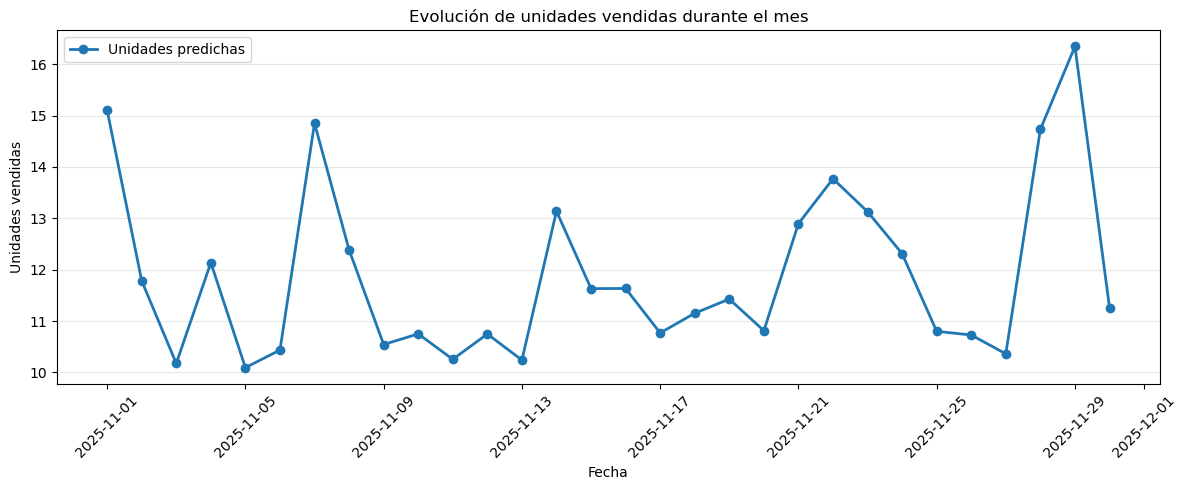

In [11]:
# Evolución de unidades vendidas a lo largo de noviembre
resultado_grafico = resultado.sort_values('fecha').copy()

plt.figure(figsize=(12, 5))
plt.plot(
    resultado_grafico['fecha'],
    resultado_grafico['unidades_predichas'],
    marker='o',
    linewidth=2,
    label='Unidades predichas'
 )

if 'unidades_vendidas' in resultado_grafico.columns and resultado_grafico['unidades_vendidas'].notna().any():
    plt.plot(
        resultado_grafico['fecha'],
        resultado_grafico['unidades_vendidas'],
        marker='o',
        linewidth=2,
        label='Unidades reales'
    )

plt.title('Evolución de unidades vendidas durante el mes')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
resultado[resultado['fecha'].between('2025-11-26', '2025-11-30')][
    ['fecha', 'es_black_friday', 'es_cyber_monday', 'unidades_predichas']
]

,fecha,es_black_friday,es_cyber_monday,unidades_predichas
25,2025-11-26,False,False,10.728504
26,2025-11-27,False,False,10.361814
27,2025-11-28,True,False,14.731615
28,2025-11-29,False,False,16.347743
29,2025-11-30,False,False,11.263416
